In [1]:
import pandas as pd

df = pd.read_csv("data/results.csv")

In [2]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49493 entries, 0 to 49492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49493 non-null  str    
 1   home_team   49493 non-null  str    
 2   away_team   49493 non-null  str    
 3   home_score  49477 non-null  float64
 4   away_score  49477 non-null  float64
 5   tournament  49493 non-null  str    
 6   city        49493 non-null  str    
 7   country     49493 non-null  str    
 8   neutral     49493 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [3]:
df[df["home_score"].isnull()].head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49477,2026-06-28,South Africa,Canada,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49478,2026-06-29,Brazil,Japan,NaN,NaN,FIFA World Cup,Houston,United States,True
49479,2026-06-29,Germany,Paraguay,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49480,2026-06-29,Netherlands,Morocco,NaN,NaN,FIFA World Cup,Guadalupe,Mexico,True
49481,2026-06-30,Ivory Coast,Norway,NaN,NaN,FIFA World Cup,Arlington,United States,True


In [4]:
played = df[df["home_score"].notnull()]
to_predict = df[df["home_score"].isnull()]

print(played.shape)
print(to_predict.shape)

(49477, 9)
(16, 9)


In [5]:
played = played.copy()
played["date"] = pd.to_datetime(played["date"])
played.info()


<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49477 non-null  datetime64[us]
 1   home_team   49477 non-null  str           
 2   away_team   49477 non-null  str           
 3   home_score  49477 non-null  float64       
 4   away_score  49477 non-null  float64       
 5   tournament  49477 non-null  str           
 6   city        49477 non-null  str           
 7   country     49477 non-null  str           
 8   neutral     49477 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 3.1 MB


In [6]:
played["year"] = played["date"].dt.year
played[["date", "home_team", "away_team", "year"]].head()

,date,home_team,away_team,year
0,1872-11-30,Scotland,England,1872
1,1873-03-08,England,Scotland,1873
2,1874-03-07,Scotland,England,1874
3,1875-03-06,England,Scotland,1875
4,1876-03-04,Scotland,England,1876


In [7]:
played["year"].value_counts().sort_index()

year
1872       1
1873       1
1874       1
1875       1
1876       2
        ... 
2022     970
2023    1054
2024    1231
2025    1002
2026     383
Name: count, Length: 155, dtype: int64

<Axes: xlabel='year'>

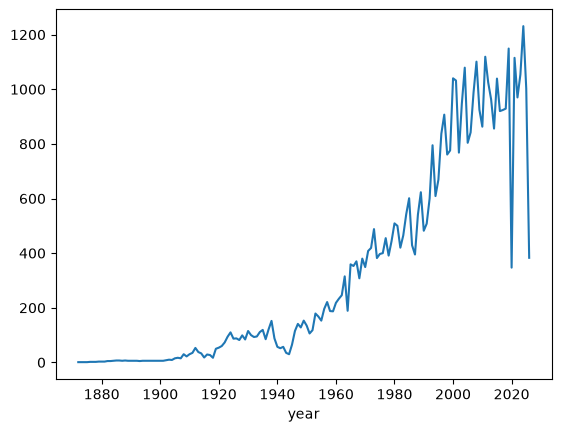

In [8]:
yearly_counts = played["year"].value_counts().sort_index()
yearly_counts.plot()

In [9]:
import numpy as np

In [10]:
conditions = [
    played["home_score"] >  played["away_score"], # If the home team wins? True/False
    played["home_score"] == played["away_score"], # If the home team draws? True/False
    played["home_score"] <  played["away_score"]  # If the home team loses? True/False
]

results = ["win", "draw", "lose"]


played["result"] = np.select(conditions, results, default="unknown")

played[["home_team", "away_team", "home_score", "away_score", "result"]].head()

,home_team,away_team,home_score,away_score,result
0,Scotland,England,0.0,0.0,draw
1,England,Scotland,4.0,2.0,win
2,Scotland,England,2.0,1.0,win
3,England,Scotland,2.0,2.0,draw
4,Scotland,England,3.0,0.0,win


In [11]:
played.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,win


In [12]:
played = played.sort_values("date").reset_index(drop = True)
played[["date", "home_team", "away_team", "result"]].head()

,date,home_team,away_team,result
0,1872-11-30,Scotland,England,draw
1,1873-03-08,England,Scotland,win
2,1874-03-07,Scotland,England,win
3,1875-03-06,England,Scotland,draw
4,1876-03-04,Scotland,England,win


In [13]:
home_view = played[["date", "home_team", "away_team", "result","home_score", "away_score" ]].copy()
home_view.columns = ["date", "team", "opponent", "result","home_score", "away_score"]
home_view["is_home"] = 1
home_view["goal_difference"] = home_view["home_score"] - home_view["away_score"]
home_view.head()


away_view = played[["date", "away_team", "home_team", "result","home_score", "away_score"]].copy()
away_view.columns = ["date", "team", "opponent", "result","home_score", "away_score"]
away_view["is_home"] = 0
away_view["goal_difference"] = away_view["away_score"] - away_view["home_score"]

flip = {"win": "lose", "lose": "win", "draw": "draw"}
away_view["result"] = away_view["result"].map(flip)
away_view.head()

team_matches = pd.concat([home_view, away_view], ignore_index= True)
team_matches = team_matches.sort_values("date").reset_index(drop=True)
print(team_matches.shape)
team_matches.head(10)


(98954, 8)


,date,team,opponent,result,home_score,away_score,is_home,goal_difference
0,1872-11-30,Scotland,England,draw,0.0,0.0,1,0.0
1,1872-11-30,England,Scotland,draw,0.0,0.0,0,0.0
2,1873-03-08,England,Scotland,win,4.0,2.0,1,2.0
3,1873-03-08,Scotland,England,lose,4.0,2.0,0,-2.0
4,1874-03-07,Scotland,England,win,2.0,1.0,1,1.0
5,1874-03-07,England,Scotland,lose,2.0,1.0,0,-1.0
6,1875-03-06,England,Scotland,draw,2.0,2.0,1,0.0
7,1875-03-06,Scotland,England,draw,2.0,2.0,0,0.0
8,1876-03-04,England,Scotland,lose,3.0,0.0,0,-3.0
9,1876-03-04,Scotland,England,win,3.0,0.0,1,3.0


In [14]:
team_matches["is_win"] = (team_matches["result"] == "win").astype(int)
team_matches["is_draw"] = (team_matches["result"] == "draw").astype(int)

team_matches["pre_win_rate"] = (
    team_matches.groupby("team")["is_win"]
    .transform(lambda x: x.shift().expanding().mean()))

team_matches["pre_draw_rate"] = (
    team_matches.groupby("team")["is_draw"]
    .transform(lambda x: x.shift().expanding().mean()))

team_matches[team_matches["team"] == "Scotland"][
    ["date", "result", "is_win", "is_draw", "pre_win_rate", "pre_draw_rate"]
].head(10)

,date,result,is_win,is_draw,pre_win_rate,pre_draw_rate
0,1872-11-30,draw,0,1,NaN,NaN
3,1873-03-08,lose,0,0,0.000000,1.000000
4,1874-03-07,win,1,0,0.000000,0.500000
7,1875-03-06,draw,0,1,0.333333,0.333333
9,1876-03-04,win,1,0,0.250000,0.500000
11,1876-03-25,win,1,0,0.400000,0.400000
12,1877-03-03,win,1,0,0.500000,0.333333
15,1877-03-05,win,1,0,0.571429,0.285714
17,1878-03-02,win,1,0,0.625000,0.250000
19,1878-03-23,win,1,0,0.666667,0.222222


In [15]:
features = team_matches[["date", "team", "pre_win_rate", "pre_draw_rate"]]

# ===== Issue log: merge row explosion =====
# Symptom: After merging on date+team, played rows grew from 49433 to 49775.
# Cause: In early football history, some teams played multiple matches on the
#        same day (e.g. Argentina in 1916), so date+team is NOT unique in features.
# Cartesian product effect: if a team plays n matches on one day, played has n rows
#        and features has n rows. merge pairs them all => n x n = n² rows
#        (quadratic blow-up), and produces WRONG feature pairings.
#        Example: 2 matches on a day -> 2x2 = 4 rows (2 extra wrong rows).
# Fix: before merging, drop duplicates on date+team so the key is unique.
#      Trade-off: win rate for same-day multi-matches is approximated
#      (only 0.6% of data, acceptable).

dup = features[features.duplicated(subset=["date", "team"], keep=False)]
# print(dup.shape)
dup.sort_values(["team", "date"]).head(20)

features_unique = features.drop_duplicates(subset=["date", "team"], keep="first")
# print(features_unique.shape)


home_features = features_unique.rename(columns = {
    "team" : "home_team",
    "pre_win_rate": "home_pre_win_rate",
    "pre_draw_rate": "home_pre_draw_rate",
})

# print(home_features.shape)

played = played.merge(home_features, on = ["date", "home_team"], how = "left")

away_features = features_unique.rename(columns = {
    "team" : "away_team",
    "pre_win_rate": "away_pre_win_rate",
    "pre_draw_rate": "away_pre_draw_rate",
})

# print(away_features.shape)

played = played.merge(away_features, on = ["date", "away_team"], how = "left")
print(played.shape)
played.head(10)

(49477, 15)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,result,home_pre_win_rate,home_pre_draw_rate,away_pre_win_rate,away_pre_draw_rate
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,draw,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,win,0.000000,1.000000,0.000000,1.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,win,0.000000,0.500000,0.500000,0.500000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,draw,0.333333,0.333333,0.333333,0.333333
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,win,0.250000,0.500000,0.250000,0.500000
5,1876-03-25,Scotland,Wales,4.0,0.0,Friendly,Glasgow,Scotland,False,1876,win,0.400000,0.400000,NaN,NaN
6,1877-03-03,England,Scotland,1.0,3.0,Friendly,London,England,False,1877,lose,0.200000,0.400000,0.500000,0.333333
7,1877-03-05,Wales,Scotland,0.0,2.0,Friendly,Wrexham,Wales,False,1877,lose,0.000000,0.000000,0.571429,0.285714
8,1878-03-02,Scotland,England,7.0,2.0,Friendly,Glasgow,Scotland,False,1878,win,0.625000,0.250000,0.166667,0.333333
9,1878-03-23,Scotland,Wales,9.0,0.0,Friendly,Glasgow,Scotland,False,1878,win,0.666667,0.222222,0.000000,0.000000


In [16]:
played[["home_pre_win_rate", "home_pre_draw_rate", "away_pre_win_rate", "away_pre_draw_rate"]].isnull().sum()

played_clean = played.dropna(subset = ["home_pre_win_rate", 
                                       "home_pre_draw_rate", 
                                       "away_pre_win_rate", 
                                       "away_pre_draw_rate"])

print(played.shape)
print(played_clean.shape)

(49477, 15)
(49175, 15)


In [17]:
print(played_clean["date"].max())
print(played_clean["date"].min())

2026-06-27 00:00:00
1873-03-08 00:00:00


In [18]:
date_to_split = "2019-01-01"

train = played_clean[played_clean["date"] < date_to_split]
test = played_clean[played_clean["date"] >= date_to_split]

print(train.shape)
print(test.shape)

features_cols = ["home_pre_win_rate", "home_pre_draw_rate", 
                "away_pre_win_rate", "away_pre_draw_rate"]

x_train = train[features_cols]
y_train = train["result"]

x_test = test[features_cols]
y_test = test["result"]

print("X_train:", x_train.shape)
print("y_train:", y_train.shape)


(41935, 15)
(7240, 15)
X_train: (41935, 4)
y_train: (41935,)


类别顺序: ['draw' 'lose' 'win']
[[0.26609663 0.254515   0.47938837]
 [0.27091105 0.22347037 0.50561858]
 [0.25883308 0.21106678 0.53010015]
 [0.24647276 0.2355498  0.51797743]
 [0.26014524 0.1888457  0.55100907]]
['win' 'win' 'win' 'win' 'win']
result
win     0.479144
lose    0.292403
draw    0.228453
Name: proportion, dtype: float64
模型准确率: 0.556353591160221
Majority baseline: 0.4796
模型 Log Loss: 0.9458857288643008
Class order: ['draw' 'lose' 'win']


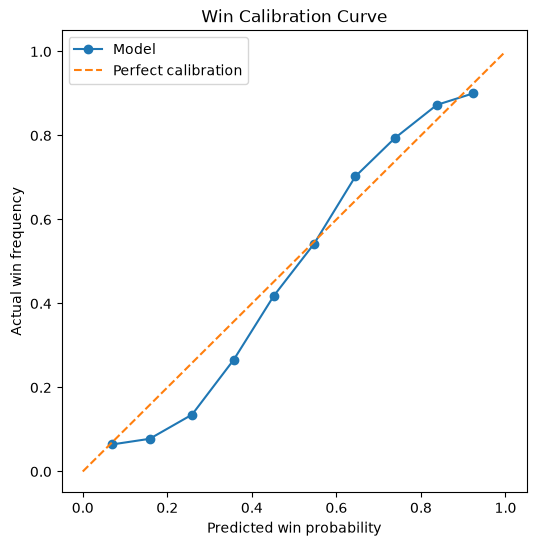

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train);

prediction_prob = model.predict_proba(x_test)
prediction = model.predict(x_test)

print(model.classes_)

print(prediction_prob[:5])
print(prediction[:5])

print(y_test.value_counts(normalize=True))

from sklearn.metrics import accuracy_score, log_loss

acc = accuracy_score(y_test, prediction)
print("Model Accuracy:", acc)
print("Majority baseline:", 0.4796)

ll = log_loss(y_test, prediction_prob)
print("Model Log Loss:", ll)

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get the predicted probability for the "win" class
# (must check classes_ to know which column is "win")
print("Class order:", model.classes_)
win_index = list(model.classes_).index("win")   # find which column is "win"
win_prob = prediction_prob[:, win_index]          # take the "win" probability column

# Actual outcome: was it a win? (1 = yes, 0 = no)
y_test_win = (y_test == "win").astype(int)

# Compute the calibration curve
# true_freq = actual win frequency per bin, pred_prob = avg predicted prob per bin
true_freq, pred_prob = calibration_curve(y_test_win, win_prob, n_bins=10)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(pred_prob, true_freq, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.xlabel("Predicted win probability")
plt.ylabel("Actual win frequency")
plt.title("Win Calibration Curve")
plt.legend()
plt.show()

In [20]:
print(played_clean["neutral"].dtype)
print(played_clean["neutral"].value_counts())

bool
neutral
False    36161
True     13014
Name: count, dtype: int64


In [21]:

train = train.copy()
test = test.copy()


train["neutral_int"] = train["neutral"].astype(int)
test["neutral_int"] = test["neutral"].astype(int)

feature_cols_v2 = ["home_pre_win_rate", "home_pre_draw_rate",
                   "away_pre_win_rate", "away_pre_draw_rate",
                   "neutral_int"]

x_train_v2 = train[feature_cols_v2]
x_test_v2 = test[feature_cols_v2]

print(x_train_v2.shape)

(41935, 5)


In [ ]:
model_v2 = LogisticRegression(max_iter = 1000)
model_v2.fit(x_train_v2, y_train)

print(x_test_v2.isnull().sum())

prediction_prob_train_v2 = model_v2.predict_proba(x_train_v2)
prediction_train_v2 = model_v2.predict(x_train_v2)
train_acc_v2 = accuracy_score(y_train, prediction_train_v2)
train_ll_v2 = log_loss(y_train, prediction_prob_train_v2)

prediction_prob__test_v2 = model_v2.predict_proba(x_test_v2)
prediction_test_v2 = model_v2.predict(x_test_v2)

# accuracy and log loss for test dataset proformance
test_acc_v2 = accuracy_score(y_test, prediction_test_v2)
test_ll_v2 = log_loss(y_test, prediction_prob__test_v2)

print("=== With neutral feature (v2) ===")
print(f"Test accuracy: {test_acc_v2:.4f}  (old v1: 0.5566)")
print(f"Test log loss: {test_ll_v2:.4f}  (old v1: 0.9455)")
print(f"--- Overfitting check ---")
print(f"Train accuracy: {train_acc_v2:.4f}  vs Test: test_acc_v2:.4f")
print(f"Train log loss: {train_ll_v2:.4f}  vs Test: test_ll_v2:.4f")


home_pre_win_rate     0
home_pre_draw_rate    0
away_pre_win_rate     0
away_pre_draw_rate    0
neutral_int           0
dtype: int64
=== 加 neutral 后 (v2) ===
测试 accuracy: 0.5681  (旧 v1: 0.5566)
测试 log loss: 0.9399  (旧 v1: 0.9455)
--- 过拟合检查 ---
训练 accuracy: 0.5531  vs 测试: test_acc_v2:.4f
训练 log loss: 0.9551  vs 测试: test_ll_v2:.4f


In [23]:
elo_df = played_clean.sort_values("date").reset_index(drop = True)
print(elo_df.shape)
print(elo_df[["date", "home_team", "away_team", "result"]].head())

(49175, 15)
        date home_team away_team result
0 1873-03-08   England  Scotland    win
1 1874-03-07  Scotland   England    win
2 1875-03-06   England  Scotland   draw
3 1876-03-04  Scotland   England    win
4 1877-03-03   England  Scotland   lose


In [24]:
elo_ratings = {}
INITIAL_ELO = 1500
K = 30
HOME_ADV = 100       
ELO_SCALE = 400 

home_elos = []
away_elos = []

for index, row in elo_df.iterrows():
    home = row["home_team"]
    away = row["away_team"]
    result = row["result"]
    is_neutral = row["neutral"]

    home_elo = elo_ratings.get(home, 1500)
    away_elo = elo_ratings.get(away, 1500)

    home_elos.append(home_elo)
    away_elos.append(away_elo)

    home_adv = HOME_ADV if not is_neutral else 0

    expected_home = 1 / (1 + 10 ** ((away_elo - (home_elo + home_adv)) / ELO_SCALE))

    if result == "win":
        actual_home = 1.0
    elif result == "draw":
        actual_home = 0.5
    else:
        actual_home = 0

    elo_ratings[home] = home_elo + K * (actual_home - expected_home)
    elo_ratings[away] = away_elo + K * ((1 - actual_home) - (1 - expected_home))

elo_df["home_elo"] = home_elos
elo_df["away_elo"] = away_elos
elo_df["elo_diff"] = elo_df["home_elo"] - elo_df["away_elo"]

print(elo_df[["date", "home_team", "away_team", "home_elo", "away_elo", "elo_diff", "result"]].head(10))


        date home_team away_team     home_elo     away_elo   elo_diff result
0 1873-03-08   England  Scotland  1500.000000  1500.000000   0.000000    win
1 1874-03-07  Scotland   England  1489.201950  1510.798050 -21.596100    win
2 1875-03-06   England  Scotland  1499.126706  1500.873294  -1.746588   draw
3 1876-03-04  Scotland   England  1505.005658  1494.994342  10.011315    win
4 1877-03-03   England  Scotland  1484.591300  1515.408700 -30.817400   lose
5 1877-03-05     Wales  Scotland  1500.000000  1533.356693 -33.356693   lose
6 1878-03-02  Scotland   England  1551.199140  1466.643307  84.555833    win
7 1878-03-23  Scotland     Wales  1558.904737  1482.157553  76.747184    win
8 1879-01-18   England     Wales  1458.937711  1474.191754 -15.254043    win
9 1879-04-05   England  Scotland  1470.349808  1566.870536 -96.520727    win


In [25]:
elo_df["neutral_int"] = elo_df["neutral"].astype(int)

train_end = "2016-01-01"
test_start = "2019-01-01"

train = elo_df[elo_df["date"] < train_end]
validation = elo_df[(elo_df["date"] >= train_end) & (elo_df["date"] < test_start)]
test = elo_df[elo_df["date"] >= test_start]

print("train:", train.shape)
print("valid:", validation.shape)
print("test: ", test.shape)

train: (39174, 19)
valid: (2761, 19)
test:  (7240, 19)


In [26]:
base = ["home_pre_win_rate", "home_pre_draw_rate",
        "away_pre_win_rate", "away_pre_draw_rate", "neutral_int"]

# Different ELO feature combinations to compare
combos = {
    "A: base (no ELO)":      base,
    "B: +elo_diff":          base + ["elo_diff"],
    "C: +home/away elo":     base + ["home_elo", "away_elo"],
    "D: +all ELO":           base + ["elo_diff", "home_elo", "away_elo"],
}

y_train = train["result"]
y_val = validation["result"]

# Train each combo on TRAIN, evaluate on VALIDATION (never touch test here)
print("=== Validation comparison (log loss, lower is better) ===")
for name, cols in combos.items():
    m = LogisticRegression(max_iter = 1000)
    x_train = train[cols]
    x_val = validation[cols]
    m.fit(x_train, y_train)

    va_prob = m.predict_proba(x_val)
    va_prediction = m.predict(x_val)

    va_ll = log_loss(y_val, va_prob)
    va_acc = accuracy_score(y_val, va_prediction)
    tr_ll = log_loss(y_train,m.predict_proba(x_train))
    tr_acc = accuracy_score(y_train, m.predict(x_train))
    
    print(f"{name:20s}  train_log loss: {tr_ll:.4f}   train_acc: {tr_acc:.4f}")
    print(f"{name:20s}  val_log loss: {va_ll:.4f}   val_acc: {va_acc:.4f}")

=== Validation comparison (log loss, lower is better) ===
A: base (no ELO)      train_log loss: 0.9537   train_acc: 0.5537
A: base (no ELO)      val_log loss: 0.9753   val_acc: 0.5353


c:\Projects\WorldCupPredictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


B: +elo_diff          train_log loss: 0.9149   train_acc: 0.5766
B: +elo_diff          val_log loss: 0.9137   val_acc: 0.5708


c:\Projects\WorldCupPredictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C: +home/away elo     train_log loss: 0.9146   train_acc: 0.5768
C: +home/away elo     val_log loss: 0.9138   val_acc: 0.5708
D: +all ELO           train_log loss: 0.9149   train_acc: 0.5772
D: +all ELO           val_log loss: 0.9150   val_acc: 0.5701


c:\Projects\WorldCupPredictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["home_pre_win_rate", "home_pre_draw_rate",
                "away_pre_win_rate", "away_pre_draw_rate",
                "neutral_int", "elo_diff"]

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(train[feature_cols])
x_valid_scaled = scaler.transform(validation[feature_cols])
x_test_scaled = scaler.transform(test[feature_cols])

print("x_train_scaled shape:", x_train_scaled.shape)
print("Mean of each feature after scaling (train):", x_train_scaled.mean(axis=0).round(3))
print("Std of each feature after scaling (train):", x_train_scaled.std(axis=0).round(3))

x_train_scaled shape: (39174, 6)
Mean of each feature after scaling (train): [-0. -0.  0.  0.  0.  0.]
Std of each feature after scaling (train): [1. 1. 1. 1. 1. 1.]


In [28]:
# Train logistic regression on the SCALED features
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(x_train_scaled, train["result"])

# Predict on validation (use scaled features)
val_prob = model_scaled.predict_proba(x_valid_scaled)
val_pred = model_scaled.predict(x_valid_scaled)

# Evaluate on validation
y_val = validation["result"]
val_ll = log_loss(y_val, val_prob)
val_acc = accuracy_score(y_val, val_pred)

# Check overfitting: train performance
train_prob = model_scaled.predict_proba(x_train_scaled)
train_ll = log_loss(train["result"], train_prob)

print(f"Validation log loss: {val_ll:.4f}  (before scaling: 0.9138)")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Train log loss:      {train_ll:.4f}  (overfit check vs val)")

Validation log loss: 0.9137  (before scaling: 0.9138)
Validation accuracy: 0.5701
Train log loss:      0.9149  (overfit check vs val)


In [29]:
print(team_matches.shape)
print(team_matches.columns.tolist())

WINDOW = 10
windows = [3, 5, WINDOW]

for w in windows:
    team_matches[f"last{w}_win_rate"] = (
        team_matches.groupby("team")["is_win"]
        .transform(lambda x: x.shift().rolling(w).mean())
    )
    team_matches[f"last{w}_draw_rate"] = (
        team_matches.groupby("team")["is_draw"]
        .transform(lambda x: x.shift().rolling(w).mean())
    )

# Check
print(team_matches[team_matches["team"] == "Scotland"][
    ["date", "result", "last3_win_rate", "last5_win_rate", "last10_win_rate"]
].head(12))

print(team_matches.head())


(98954, 12)
['date', 'team', 'opponent', 'result', 'home_score', 'away_score', 'is_home', 'goal_difference', 'is_win', 'is_draw', 'pre_win_rate', 'pre_draw_rate']
         date result  last3_win_rate  last5_win_rate  last10_win_rate
0  1872-11-30   draw             NaN             NaN              NaN
3  1873-03-08   lose             NaN             NaN              NaN
4  1874-03-07    win             NaN             NaN              NaN
7  1875-03-06   draw        0.333333             NaN              NaN
9  1876-03-04    win        0.333333             NaN              NaN
11 1876-03-25    win        0.666667             0.4              NaN
12 1877-03-03    win        0.666667             0.6              NaN
15 1877-03-05    win        1.000000             0.8              NaN
17 1878-03-02    win        1.000000             0.8              NaN
19 1878-03-23    win        1.000000             1.0              NaN
22 1879-04-05   lose        1.000000             1.0              0

In [30]:
rolling_cols = [f"last{w}_win_rate" for w in [3, 5, 10]] + \
               [f"last{w}_draw_rate" for w in [3, 5, 10]]

roll_features = team_matches[["date", "team"] + rolling_cols]
roll_features = roll_features.drop_duplicates(subset=["date", "team"], keep="first")

home_roll = roll_features.rename(columns = {
    "team" : "home_team",
    **{c : f"home_{c}" for c in rolling_cols}
})


elo_df = elo_df.merge(home_roll, on=["date", "home_team"], how="left")


away_roll = roll_features.rename(columns = {
    "team" : "away_team",
    **{c : f"away_{c}" for c in rolling_cols}
})

elo_df = elo_df.merge(away_roll, on=["date", "away_team"], how="left")

print("elo_df shape:", elo_df.shape)
print("Rolling cols:", [c for c in elo_df.columns if "last" in c])
print(elo_df[["date", "home_team", "away_team",
              "home_last5_win_rate", "away_last5_win_rate"]].head(10))


elo_df shape: (49175, 31)
Rolling cols: ['home_last3_win_rate', 'home_last5_win_rate', 'home_last10_win_rate', 'home_last3_draw_rate', 'home_last5_draw_rate', 'home_last10_draw_rate', 'away_last3_win_rate', 'away_last5_win_rate', 'away_last10_win_rate', 'away_last3_draw_rate', 'away_last5_draw_rate', 'away_last10_draw_rate']
        date home_team away_team  home_last5_win_rate  away_last5_win_rate
0 1873-03-08   England  Scotland                  NaN                  NaN
1 1874-03-07  Scotland   England                  NaN                  NaN
2 1875-03-06   England  Scotland                  NaN                  NaN
3 1876-03-04  Scotland   England                  NaN                  NaN
4 1877-03-03   England  Scotland                  0.2                  0.6
5 1877-03-05     Wales  Scotland                  NaN                  0.8
6 1878-03-02  Scotland   England                  0.8                  0.2
7 1878-03-23  Scotland     Wales                  1.0                  Na

In [31]:
roll_cols_merged = [c for c in elo_df.columns if "last" in c]
print(elo_df[roll_cols_merged].isnull().sum())
print("\nTotal rows:", len(elo_df))

elo_df_clean = elo_df.dropna(subset = roll_cols_merged)
print("Before:", elo_df.shape)
print("After: ", elo_df_clean.shape)
print("Dropped:", len(elo_df) - len(elo_df_clean), "rows")

home_last3_win_rate       275
home_last5_win_rate       574
home_last10_win_rate     1238
home_last3_draw_rate      275
home_last5_draw_rate      574
home_last10_draw_rate    1238
away_last3_win_rate       335
away_last5_win_rate       614
away_last10_win_rate     1358
away_last3_draw_rate      335
away_last5_draw_rate      614
away_last10_draw_rate    1358
dtype: int64

Total rows: 49175
Before: (49175, 31)
After:  (47065, 31)
Dropped: 2110 rows


In [32]:
# Re-split from the cleaned data (with rolling features)
train_end = "2016-01-01"
test_start = "2019-01-01"

train = elo_df_clean[elo_df_clean["date"] < train_end]
validation = elo_df_clean[(elo_df_clean["date"] >= train_end) & (elo_df_clean["date"] < test_start)]
test = elo_df_clean[elo_df_clean["date"] >= test_start]

print("train:", train.shape)
print("valid:", validation.shape)
print("test: ", test.shape)

train: (37185, 31)
valid: (2684, 31)
test:  (7196, 31)


In [33]:
from sklearn.preprocessing import StandardScaler

# Rolling feature columns
roll_cols_merged = [c for c in elo_df.columns if "last" in c]

# Two feature sets to compare
base_feats = ["home_pre_win_rate", "home_pre_draw_rate",
              "away_pre_win_rate", "away_pre_draw_rate",
              "neutral_int", "elo_diff"]
roll_feats = base_feats + roll_cols_merged   # base + 12 rolling features

combos = {
    "Base (no rolling)": base_feats,
    "Base + rolling":    roll_feats,
}

y_tr = train["result"]
y_va = validation["result"]

print("=== Validation comparison (log loss, lower is better) ===")
for name, cols in combos.items():
    # Standardize (fit on train only - leakage-safe)
    scaler = StandardScaler()
    x_tr = scaler.fit_transform(train[cols])
    x_va = scaler.transform(validation[cols])

    # Train and evaluate
    m = LogisticRegression(max_iter=1000)
    m.fit(x_tr, y_tr)
    va_ll = log_loss(y_va, m.predict_proba(x_va))
    va_acc = accuracy_score(y_va, m.predict(x_va))
    tr_ll = log_loss(y_tr, m.predict_proba(x_tr))

    print(f"{name:20s}  val_ll: {va_ll:.4f}   val_acc: {va_acc:.4f}   train_ll: {tr_ll:.4f}")
# Conclusion: Adding rolling win rate is not helpful in prediction. This might be explained by having elo df already


=== Validation comparison (log loss, lower is better) ===
Base (no rolling)     val_ll: 0.9075   val_acc: 0.5738   train_ll: 0.9128
Base + rolling        val_ll: 0.9067   val_acc: 0.5708   train_ll: 0.9121


In [34]:
print(elo_df_clean["tournament"].value_counts().head(20))
print("\nTotal unique tournaments:", elo_df_clean["tournament"].nunique())

# Top-tier continental + world tournaments (finals, not qualifiers)
major_tournaments = [
    "FIFA World Cup",
    "UEFA Euro",
    "Copa América",
    "AFC Asian Cup",
    "African Cup of Nations",
]

# ===== Scheme B: ordinal importance (0/1/2/3) =====
def tournament_importance(t):
    if t == "Friendly":
        return 0
    elif "qualification" in t:
        return 1
    elif t in major_tournaments:
        return 3   # Top-tier major
    else:
        return 2   # Other tournaments

elo_df_clean["tournament_importance"] = elo_df_clean["tournament"].apply(tournament_importance)

# ===== Scheme C: independent binary flags =====
elo_df_clean["is_friendly"] = (elo_df_clean["tournament"] == "Friendly").astype(int)
elo_df_clean["is_qualification"] = elo_df_clean["tournament"].str.contains("qualification").astype(int)
elo_df_clean["is_major"] = elo_df_clean["tournament"].isin(major_tournaments).astype(int)

# Check
# print("Scheme B (importance) distribution:")
# print(elo_df_clean["tournament_importance"].value_counts().sort_index())

# print("\nScheme C flag counts:")
# print("is_friendly:     ", elo_df_clean["is_friendly"].sum())
# print("is_qualification:", elo_df_clean["is_qualification"].sum())
# print("is_major:        ", elo_df_clean["is_major"].sum())

tournament
Friendly                                17241
FIFA World Cup qualification             8703
UEFA Euro qualification                  2792
African Cup of Nations qualification     2296
FIFA World Cup                           1029
African Cup of Nations                    840
Copa América                              838
AFC Asian Cup qualification               810
UEFA Nations League                       658
CECAFA Cup                                609
Merdeka Tournament                        568
CFU Caribbean Cup qualification           544
British Home Championship                 517
CONCACAF Nations League                   422
Gold Cup                                  420
AFC Asian Cup                             416
UEFA Euro                                 388
Gulf Cup                                  385
COSAFA Cup                                354
Asian Games                               338
Name: count, dtype: int64

Total unique tournaments: 188


In [35]:
roll_cols_merged = [c for c in elo_df_clean.columns if "last" in c]

base_feats = ["home_pre_win_rate", "home_pre_draw_rate",
              "away_pre_win_rate", "away_pre_draw_rate",
              "neutral_int", "elo_diff"]

combos = {
    "Base":               base_feats,
    "Base + B (ordinal)": base_feats + ["tournament_importance"],
    "Base + C (flags)":   base_feats + ["is_friendly", "is_qualification", "is_major"],
    "Base + B + C":       base_feats + ["tournament_importance", "is_friendly", "is_qualification", "is_major"],
}

# Re-split (elo_df_clean now has the new tournament features)
train_end, test_start = "2016-01-01", "2019-01-01"
train = elo_df_clean[elo_df_clean["date"] < train_end]
validation = elo_df_clean[(elo_df_clean["date"] >= train_end) & (elo_df_clean["date"] < test_start)]

y_tr, y_va = train["result"], validation["result"]

print("=== Validation comparison (log loss, lower is better) ===")
for name, cols in combos.items():
    scaler = StandardScaler()
    x_tr = scaler.fit_transform(train[cols])
    x_va = scaler.transform(validation[cols])
    m = LogisticRegression(max_iter=1000)
    m.fit(x_tr, y_tr)
    va_ll = log_loss(y_va, m.predict_proba(x_va))
    va_acc = accuracy_score(y_va, m.predict(x_va))
    print(f"{name:22s}  val_ll: {va_ll:.4f}   val_acc: {va_acc:.4f}")

=== Validation comparison (log loss, lower is better) ===
Base                    val_ll: 0.9075   val_acc: 0.5738
Base + B (ordinal)      val_ll: 0.9072   val_acc: 0.5753
Base + C (flags)        val_ll: 0.9063   val_acc: 0.5756
Base + B + C            val_ll: 0.9063   val_acc: 0.5756


In [36]:
# Goal Differnce(GD) Column

team_matches["cum_goal_diff"] = (team_matches.groupby("team")["goal_difference"]
    .transform(lambda x : x. shift().expanding().mean()))

team_matches["last5_goal_diff"] = (team_matches.groupby("team")["goal_difference"]
    .transform(lambda x : x. shift().rolling(5).mean()))

print(team_matches.head(6))

goal_diff_cols = ["cum_goal_diff", "last5_goal_diff"]
goal_diff_features = team_matches[["team", "date"] + goal_diff_cols]
goal_diff_features = goal_diff_features.drop_duplicates(subset = ["date", "team"], keep = "first") 

home_goal_diff = goal_diff_features.rename(columns = {
    "team" :"home_team",
    **{c : f"home_{c}" for c in goal_diff_cols}
} )

away_goal_diff = goal_diff_features.rename(columns = {
    "team" :"away_team",
    **{c : f"away_{c}" for c in goal_diff_cols}
} )

new_df = elo_df_clean.copy()
new_df = new_df.merge(home_goal_diff, on = ["date", "home_team"], how = "left")
new_df = new_df.merge(away_goal_diff, on = ["date", "away_team"], how = "left")

# print(new_df.head(6))


        date      team  opponent result  home_score  away_score  is_home  \
0 1872-11-30  Scotland   England   draw         0.0         0.0        1   
1 1872-11-30   England  Scotland   draw         0.0         0.0        0   
2 1873-03-08   England  Scotland    win         4.0         2.0        1   
3 1873-03-08  Scotland   England   lose         4.0         2.0        0   
4 1874-03-07  Scotland   England    win         2.0         1.0        1   
5 1874-03-07   England  Scotland   lose         2.0         1.0        0   

   goal_difference  is_win  is_draw  pre_win_rate  pre_draw_rate  \
0              0.0       0        1           NaN            NaN   
1              0.0       0        1           NaN            NaN   
2              2.0       1        0           0.0            1.0   
3             -2.0       0        0           0.0            1.0   
4              1.0       1        0           0.0            0.5   
5             -1.0       0        0           0.5          

In [ ]:
# Check NaN in the new goal_diff features
goal_diff_merged = [c for c in new_df.columns if "goal_diff" in c]
print("NaN in goal_diff features:")
print(new_df[goal_diff_merged].isnull().sum())

# Drop rows where any goal_diff feature is NaN
new_df_clean = new_df.dropna(subset=goal_diff_merged)
print("\nBefore:", new_df.shape)
print("After: ", new_df_clean.shape)
print("Dropped:", len(new_df) - len(new_df_clean), "rows")

NaN in goal_diff features:
home_cum_goal_diff      0
home_last5_goal_diff    0
away_cum_goal_diff      0
away_last5_goal_diff    0
dtype: int64

Before: (47065, 39)
After:  (47065, 39)
Dropped: 0 rows


In [ ]:
base_feats = ["home_pre_win_rate", "home_pre_draw_rate",
              "away_pre_win_rate", "away_pre_draw_rate",
              "neutral_int", "elo_diff",
              "is_friendly", "is_qualification", "is_major"]

combos = {
    "Base (no goal_diff)":  base_feats,
    "Base + cum_goal_diff": base_feats + ["home_cum_goal_diff", "away_cum_goal_diff"],
    "Base + last5_goal_diff": base_feats + ["home_last5_goal_diff", "away_last5_goal_diff"],
    "Base + both goal_diff": base_feats + ["home_cum_goal_diff", "away_cum_goal_diff",
                                            "home_last5_goal_diff", "away_last5_goal_diff"],
}

# Re-split from new_df
train_end, test_start = "2016-01-01", "2019-01-01"
train = new_df_clean[new_df_clean["date"] < train_end]
validation = new_df_clean[(new_df_clean["date"] >= train_end) & (new_df_clean["date"] < test_start)]
y_tr, y_va = train["result"], validation["result"]

print("=== Validation comparison (log loss, lower is better) ===")
for name, cols in combos.items():
    scaler = StandardScaler()
    x_tr = scaler.fit_transform(train[cols])
    x_va = scaler.transform(validation[cols])
    m = LogisticRegression(max_iter=1000)
    m.fit(x_tr, y_tr)
    va_ll = log_loss(y_va, m.predict_proba(x_va))
    va_acc = accuracy_score(y_va, m.predict(x_va))
    print(f"{name:24s}  val_ll: {va_ll:.4f}   val_acc: {va_acc:.4f}")

=== Validation comparison (log loss, lower is better) ===
Base (no goal_diff)       val_ll: 0.9063   val_acc: 0.5756
Base + cum_goal_diff      val_ll: 0.9032   val_acc: 0.5756
Base + last5_goal_diff    val_ll: 0.9037   val_acc: 0.5719
Base + both goal_diff     val_ll: 0.9017   val_acc: 0.5753


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Wider feature pool — let Lasso decide what's useful
wide_feats = [
    # base rates
    "home_pre_win_rate", "home_pre_draw_rate", "away_pre_win_rate", "away_pre_draw_rate",
    # ELO: include BOTH diff AND separate (let Lasso pick the best combo)
    "elo_diff", "home_elo", "away_elo",
    # venue
    "neutral_int",
    # tournament
    "is_friendly", "is_qualification", "is_major",
    # goal diff
    "home_cum_goal_diff", "away_cum_goal_diff",
    "home_last5_goal_diff", "away_last5_goal_diff",
    # rolling (previously excluded — let Lasso judge in combination)
    "home_last5_win_rate", "away_last5_win_rate",
    "home_last10_win_rate", "away_last10_win_rate",
]

train = new_df_clean[new_df_clean["date"] < train_end]

scaler = StandardScaler()
x_train = scaler.fit_transform(train[wide_feats])
y_train = train["result"]

param_grid = {
    "l1_ratio": [0, 0.25, 0.5, 0.75, 1],
    "C" : [10**i for i in range(-2, 3)]
}

tscv = TimeSeriesSplit(n_splits = 5)

grid = GridSearchCV(
    LogisticRegression(max_iter=3000, solver="saga"),
    param_grid,
    cv = tscv,
    scoring="neg_log_loss",
    n_jobs=-1,
)
grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV log loss:", round(-grid.best_score_, 4))

Best params: {'C': 100, 'l1_ratio': 1}
Best CV log loss: 0.9093


In [40]:
import numpy as np

best_model = grid.best_estimator_
coefs = best_model.coef_   # (3 classes, N features)
importance = np.abs(coefs).mean(axis=0)   # avg |coef| per feature

print("Feature importance (by avg |coefficient|):")
for name, imp in sorted(zip(wide_feats, importance), key=lambda x: -x[1]):
    print(f"  {imp:.4f}  {name}")

Feature importance (by avg |coefficient|):
  0.3012  elo_diff
  0.1713  away_elo
  0.1385  home_elo
  0.1133  away_cum_goal_diff
  0.1068  neutral_int
  0.0955  away_pre_win_rate
  0.0951  home_cum_goal_diff
  0.0789  home_pre_win_rate
  0.0774  home_last5_goal_diff
  0.0729  away_last5_goal_diff
  0.0430  away_pre_draw_rate
  0.0387  home_last10_win_rate
  0.0335  home_pre_draw_rate
  0.0304  away_last5_win_rate
  0.0274  home_last5_win_rate
  0.0261  away_last10_win_rate
  0.0214  is_friendly
  0.0141  is_qualification
  0.0082  is_major


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Tree models DON'T need standardization - use raw features
x_train = train[wide_feats]
y_train = train["result"]

# Random Forest hyperparameter grid
rf_param_grid = {
    "n_estimators": [200, 300, 400, 500],         
    "max_depth": [4, 6, 8, 10, 15, 20],          
    "min_samples_leaf": [5, 10, 20, 50, 100],     
}

tscv = TimeSeriesSplit(n_splits=5)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=tscv,
    scoring="neg_log_loss",
    n_jobs=-1,
)
rf_grid.fit(x_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV log loss:", round(-rf_grid.best_score_, 4))
print("(Logistic baseline CV log loss: 0.9093)")

Best RF params: {'max_depth': 15, 'min_samples_leaf': 20, 'n_estimators': 500}
Best RF CV log loss: 0.9167
(Logistic baseline CV log loss: 0.9093)


In [ ]:

try:
    import xgboost as xgb
    print("xgboost version:", xgb.__version__)
except ImportError:
    print("xgboost NOT installed - need to install it")


xgboost version: 3.3.0


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

x_train = train[wide_feats]
y_train = train["result"]

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)   # win/draw/lose -> 0/1/2
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# XGBoost hyperparameter grid
xgb_param_grid = {
    "n_estimators": [200, 400],          # number of boosting rounds
    "max_depth": [3, 5, 7],              # tree depth 
    "learning_rate": [0.01, 0.05, 0.1],  # step size 
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        objective="multi:softprob",   
        random_state=42,
        n_jobs=-1,
    ),
    xgb_param_grid,
    cv=tscv,
    scoring="neg_log_loss",
    n_jobs=-1,
)
xgb_grid.fit(x_train, y_train_encoded)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV log loss:", round(-xgb_grid.best_score_, 4))
print("(Logistic baseline: 0.9093 | Random Forest: 0.9166)")


Label mapping: {'draw': np.int64(0), 'lose': np.int64(1), 'win': np.int64(2)}
Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best XGB CV log loss: 0.9124
(Logistic baseline: 0.9093 | Random Forest: 0.9166)


In [44]:
from sklearn.metrics import accuracy_score, log_loss

x_valid = validation[wide_feats]
y_valid = validation["result"]

# --- Logistic Regression (need scaled features) ---
scaler = StandardScaler()
x_train_s = scaler.fit_transform(train[wide_feats])
x_valid_s = scaler.transform(x_valid)
lr_best = grid.best_estimator_   # the tuned logistic regression
lr_acc = accuracy_score(y_valid, lr_best.predict(x_valid_s))
lr_ll = log_loss(y_valid, lr_best.predict_proba(x_valid_s))

# --- Random Forest (raw features) ---
rf_best = rf_grid.best_estimator_
rf_acc = accuracy_score(y_valid, rf_best.predict(x_valid))
rf_ll = log_loss(y_valid, rf_best.predict_proba(x_valid))

# --- XGBoost (raw features, encoded labels) ---
y_valid_encoded = le.transform(y_valid)
xgb_best = xgb_grid.best_estimator_
xgb_acc = accuracy_score(y_valid_encoded, xgb_best.predict(x_valid))
xgb_ll = log_loss(y_valid_encoded, xgb_best.predict_proba(x_valid))

print("=== Validation comparison ===")
print(f"Logistic Regression  acc: {lr_acc:.4f}   log loss: {lr_ll:.4f}")
print(f"Random Forest        acc: {rf_acc:.4f}   log loss: {rf_ll:.4f}")
print(f"XGBoost              acc: {xgb_acc:.4f}   log loss: {xgb_ll:.4f}")

=== Validation comparison ===
Logistic Regression  acc: 0.5816   log loss: 0.8998
Random Forest        acc: 0.5741   log loss: 0.9056
XGBoost              acc: 0.5764   log loss: 0.9027


In [45]:
print("Date range:", played["date"].min(), "to", played["date"].max())
print("\nto_predict (matches to predict):")
print(to_predict[["date", "home_team", "away_team"]].tail(10))

Date range: 1872-11-30 00:00:00 to 2026-06-27 00:00:00

to_predict (matches to predict):
             date      home_team               away_team
49483  2026-06-30         Mexico                 Ecuador
49484  2026-07-01        England                DR Congo
49485  2026-07-01        Belgium                 Senegal
49486  2026-07-01  United States  Bosnia and Herzegovina
49487  2026-07-02          Spain                 Austria
49488  2026-07-02       Portugal                 Croatia
49489  2026-07-02    Switzerland                 Algeria
49490  2026-07-03      Australia                   Egypt
49491  2026-07-03      Argentina              Cape Verde
49492  2026-07-03       Colombia                   Ghana


In [51]:
new_df_clean["home_elo"]

0        1473.525997
1        1608.634997
2        1446.111413
3        1614.391331
4        1442.020188
            ...     
47060    1717.130257
47061    1661.505443
47062    1685.320751
47063    1961.753616
47064    1878.438219
Name: home_elo, Length: 47065, dtype: float64

In [47]:
team_matches.tail(10)

,date,team,opponent,result,home_score,away_score,is_home,goal_difference,is_win,is_draw,pre_win_rate,pre_draw_rate,last3_win_rate,last3_draw_rate,last5_win_rate,last5_draw_rate,last10_win_rate,last10_draw_rate,cum_goal_diff,last5_goal_diff
98944,2026-06-27,Austria,Algeria,draw,3.0,3.0,0,0.0,0,1,0.426914,0.213457,0.666667,0.000000,0.8,0.0,0.7,0.1,0.262181,1.2
98945,2026-06-27,England,Panama,win,0.0,2.0,0,2.0,1,0,0.573260,0.237179,0.666667,0.333333,0.6,0.2,0.7,0.2,1.228938,1.0
98946,2026-06-27,Croatia,Ghana,win,2.0,1.0,1,1.0,1,0,0.527638,0.261307,0.666667,0.000000,0.4,0.0,0.6,0.1,0.721106,-0.8
98947,2026-06-27,Jordan,Argentina,lose,1.0,3.0,1,-2.0,0,0,0.369610,0.275154,0.000000,0.000000,0.0,0.2,0.3,0.2,0.154004,-1.6
98948,2026-06-27,Algeria,Austria,draw,3.0,3.0,1,0.0,0,1,0.466882,0.261712,0.666667,0.000000,0.6,0.2,0.7,0.1,0.546042,0.6
98949,2026-06-27,Panama,England,lose,0.0,2.0,1,-2.0,0,0,0.338262,0.245841,0.000000,0.333333,0.2,0.2,0.3,0.3,-0.268022,-0.8
98950,2026-06-27,Colombia,Portugal,draw,0.0,0.0,1,0.0,0,1,0.406250,0.275000,1.000000,0.000000,0.8,0.0,0.7,0.1,0.140625,1.0
98951,2026-06-27,DR Congo,Uzbekistan,win,3.0,1.0,1,2.0,1,0,0.391635,0.275665,0.000000,0.333333,0.2,0.4,0.4,0.3,0.287072,-0.2
98952,2026-06-27,Argentina,Jordan,win,1.0,3.0,0,2.0,1,0,0.554622,0.239963,1.000000,0.000000,1.0,0.0,0.9,0.0,0.894491,3.0
98953,2026-06-27,Ghana,Croatia,lose,2.0,1.0,0,-1.0,0,0,0.463596,0.261516,0.333333,0.666667,0.2,0.4,0.3,0.2,0.524517,-0.4


In [52]:
# For final prediction: train on ALL available data (no holdout needed anymore)
# Evaluation is done - now use everything to make the model as strong as possible

final_feats = wide_feats   # the features your best logistic used

# Use ALL played matches (everything, not just train split)
all_data = new_df_clean   # or new_df, all played matches with features

X_all = all_data[final_feats]
y_all = all_data["result"]

# Standardize using ALL data (fit on everything now)
final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X_all)

# Train final logistic regression with the best params (C=100, from your grid search)
from sklearn.linear_model import LogisticRegression
final_model = LogisticRegression(C=100, max_iter=5000, solver="saga")
final_model.fit(X_all_scaled, y_all)

print("Final model trained on ALL data!")
print("Training samples:", len(y_all))
print("Features:", final_feats)

Final model trained on ALL data!
Training samples: 47065
Features: ['home_pre_win_rate', 'home_pre_draw_rate', 'away_pre_win_rate', 'away_pre_draw_rate', 'elo_diff', 'home_elo', 'away_elo', 'neutral_int', 'is_friendly', 'is_qualification', 'is_major', 'home_cum_goal_diff', 'away_cum_goal_diff', 'home_last5_goal_diff', 'away_last5_goal_diff', 'home_last5_win_rate', 'away_last5_win_rate', 'home_last10_win_rate', 'away_last10_win_rate']


In [53]:

print("team_matches columns:", team_matches.columns.tolist())

team_matches columns: ['date', 'team', 'opponent', 'result', 'home_score', 'away_score', 'is_home', 'goal_difference', 'is_win', 'is_draw', 'pre_win_rate', 'pre_draw_rate', 'last3_win_rate', 'last3_draw_rate', 'last5_win_rate', 'last5_draw_rate', 'last10_win_rate', 'last10_draw_rate', 'cum_goal_diff', 'last5_goal_diff']


In [ ]:
def get_team_latest(team):
    """Get a team's most recent feature row from team_matches (latest state)."""
    team_rows = team_matches[team_matches["team"] == team].sort_values("date")
    if len(team_rows) == 0:
        return None
    return team_rows.iloc[-1]   # last (most recent) appearance


def predict_match(home_team, away_team, is_neutral=True, is_major=True, knockout=True):
    """
    Predict win/draw/lose probabilities for a future match (home perspective).
    If knockout=True, also compute advance probabilities (draw split 50-50).
    """
    home = get_team_latest(home_team)
    away = get_team_latest(away_team)
    if home is None or away is None:
        print(f"\nMissing data for {home_team} or {away_team} - check team name spelling")
        return

    home_elo = elo_ratings.get(home_team, 1500)
    away_elo = elo_ratings.get(away_team, 1500)
    elo_diff = home_elo - away_elo

    feature_values = {
        "home_pre_win_rate": home["pre_win_rate"],
        "home_pre_draw_rate": home["pre_draw_rate"],
        "away_pre_win_rate": away["pre_win_rate"],
        "away_pre_draw_rate": away["pre_draw_rate"],
        "elo_diff": elo_diff,
        "home_elo": home_elo,
        "away_elo": away_elo,
        "neutral_int": 1 if is_neutral else 0,
        "is_friendly": 0,
        "is_qualification": 0,
        "is_major": 1 if is_major else 0,
        "home_cum_goal_diff": home["cum_goal_diff"],
        "away_cum_goal_diff": away["cum_goal_diff"],
        "home_last5_goal_diff": home["last5_goal_diff"],
        "away_last5_goal_diff": away["last5_goal_diff"],
        "home_last5_win_rate": home["last5_win_rate"],
        "away_last5_win_rate": away["last5_win_rate"],
        "home_last10_win_rate": home["last10_win_rate"],
        "away_last10_win_rate": away["last10_win_rate"],
    }

    
    x = pd.DataFrame([[feature_values[f] for f in wide_feats]], columns=wide_feats)

    
    x_scaled = final_scaler.transform(x)

    
    probs = final_model.predict_proba(x_scaled)[0]
    classes = list(final_model.classes_)
    prob_dict = dict(zip(classes, probs))

    p_home_90 = prob_dict.get("win", 0)    # home wins in 90 min
    p_draw = prob_dict.get("draw", 0)      # draw in 90 min
    p_away_90 = prob_dict.get("lose", 0)   # away wins in 90 min

    #90-minute result
    venue = "neutral" if is_neutral else f"{home_team} home"
    print(f"\n{'='*52}")
    print(f"  {home_team} vs {away_team}   ({venue})")
    print(f"  ELO: {home_elo:.0f} vs {away_elo:.0f}  (diff {elo_diff:+.0f})")
    print(f"{'='*52}")
    print(f"  --- 90-minute result ---")
    print(f"  {home_team} win:  {p_home_90*100:5.1f}%")
    print(f"  Draw:        {p_draw*100:5.1f}%")
    print(f"  {away_team} win:  {p_away_90*100:5.1f}%")

    #Knockout:advance probabilities (draw split 50-50)
    if knockout:
        p_home_adv = p_home_90 + p_draw * 0.5
        p_away_adv = p_away_90 + p_draw * 0.5
        print(f"  --- Advance probability (draw split 50-50) ---")
        print(f"  {home_team} advances:  {p_home_adv*100:5.1f}%")
        print(f"  {away_team} advances:  {p_away_adv*100:5.1f}%")

    return prob_dict


In [56]:
# ============ All upcoming matches with REAL neutral flag ============
# Format: (home, away, is_neutral)  -- False means home team's real home ground
matches = [
    ("South Africa", "Canada", True),
    ("Brazil", "Japan", True),
    ("Germany", "Paraguay", True),
    ("Netherlands", "Morocco", True),
    ("Ivory Coast", "Norway", True),
    ("France", "Sweden", True),
    ("Mexico", "Ecuador", False),                        # Mexico City - Mexico home
    ("England", "DR Congo", True),
    ("Belgium", "Senegal", True),
    ("United States", "Bosnia and Herzegovina", False),  # Santa Clara - USA home
    ("Spain", "Austria", True),
    ("Portugal", "Croatia", True),
    ("Switzerland", "Algeria", True),
    ("Australia", "Egypt", True),
    ("Argentina", "Cape Verde", True),
    ("Colombia", "Ghana", True),
]

for home, away, is_neutral in matches:
    predict_match(home, away, is_neutral=is_neutral, is_major=True, knockout=True)


  South Africa vs Canada   (neutral)
  ELO: 1637 vs 1781  (diff -143)
  --- 90-minute result ---
  South Africa win:   16.4%
  Draw:         28.4%
  Canada win:   55.1%
  --- Advance probability (draw split 50-50) ---
  South Africa advances:   30.7%
  Canada advances:   69.3%

  Brazil vs Japan   (neutral)
  ELO: 1978 vs 1891  (diff +86)
  --- 90-minute result ---
  Brazil win:   50.8%
  Draw:         26.3%
  Japan win:   22.9%
  --- Advance probability (draw split 50-50) ---
  Brazil advances:   63.9%
  Japan advances:   36.1%

  Germany vs Paraguay   (neutral)
  ELO: 1911 vs 1822  (diff +89)
  --- 90-minute result ---
  Germany win:   47.2%
  Draw:         28.8%
  Paraguay win:   24.0%
  --- Advance probability (draw split 50-50) ---
  Germany advances:   61.6%
  Paraguay advances:   38.4%

  Netherlands vs Morocco   (neutral)
  ELO: 1909 vs 1900  (diff +9)
  --- 90-minute result ---
  Netherlands win:   34.8%
  Draw:         32.1%
  Morocco win:   33.1%
  --- Advance probability (